<a href="https://colab.research.google.com/github/Wambo44-master/DataScience-Projects/blob/main/TrainPerformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd

df = pd.read_csv("trainperf.csv")
print(df.shape)
print(df.head())

(4368, 10)
                         customerid  systemloanid  loannumber  \
0  8a2a81a74ce8c05d014cfb32a0da1049     301994762          12   
1  8a85886e54beabf90154c0a29ae757c0     301965204           2   
2  8a8588f35438fe12015444567666018e     301966580           7   
3  8a85890754145ace015429211b513e16     301999343           3   
4  8a858970548359cc0154883481981866     301962360           9   

                 approveddate                creationdate  loanamount  \
0  2017-07-25 08:22:56.000000  2017-07-25 07:22:47.000000     30000.0   
1  2017-07-05 17:04:41.000000  2017-07-05 16:04:18.000000     15000.0   
2  2017-07-06 14:52:57.000000  2017-07-06 13:52:51.000000     20000.0   
3  2017-07-27 19:00:41.000000  2017-07-27 18:00:35.000000     10000.0   
4  2017-07-03 23:42:45.000000  2017-07-03 22:42:39.000000     40000.0   

   totaldue  termdays referredby good_bad_flag  
0   34500.0        30        NaN          Good  
1   17250.0        30        NaN          Good  
2   22250.0 

(4368, 10)
                         customerid  systemloanid  loannumber  \
0  8a2a81a74ce8c05d014cfb32a0da1049     301994762          12   
1  8a85886e54beabf90154c0a29ae757c0     301965204           2   
2  8a8588f35438fe12015444567666018e     301966580           7   
3  8a85890754145ace015429211b513e16     301999343           3   
4  8a858970548359cc0154883481981866     301962360           9   

                 approveddate                creationdate  loanamount  \
0  2017-07-25 08:22:56.000000  2017-07-25 07:22:47.000000     30000.0   
1  2017-07-05 17:04:41.000000  2017-07-05 16:04:18.000000     15000.0   
2  2017-07-06 14:52:57.000000  2017-07-06 13:52:51.000000     20000.0   
3  2017-07-27 19:00:41.000000  2017-07-27 18:00:35.000000     10000.0   
4  2017-07-03 23:42:45.000000  2017-07-03 22:42:39.000000     40000.0   

   totaldue  termdays referredby good_bad_flag  
0   34500.0        30        NaN          Good  
1   17250.0        30        NaN          Good  
2   22250.0 

/tmp/ipykernel_3972/1947354209.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loanamount'].fillna(df['loanamount'].mean(), inplace=True)
/tmp/ipykernel_3972/1947354209.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

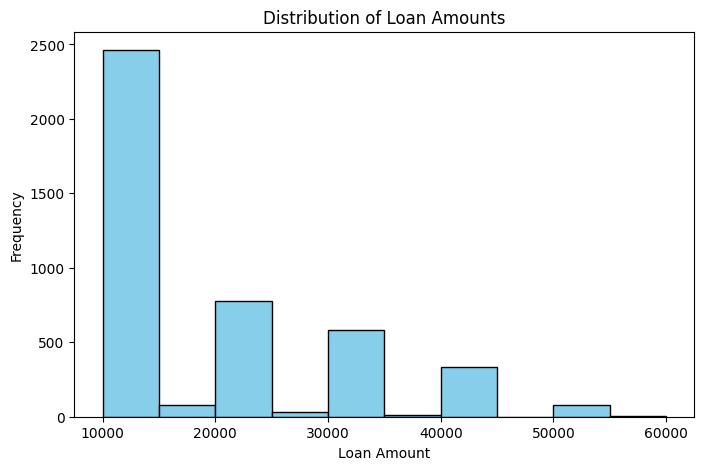

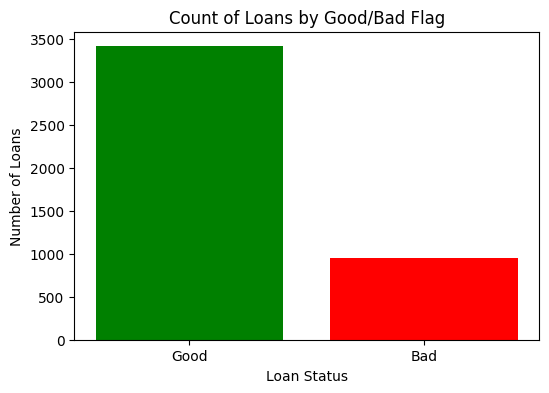

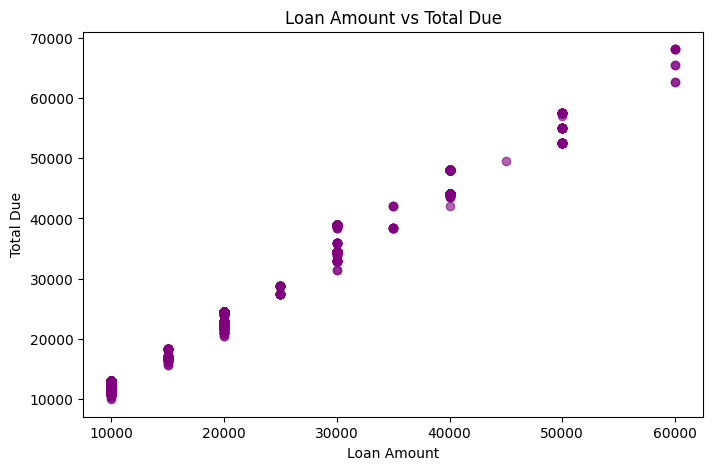

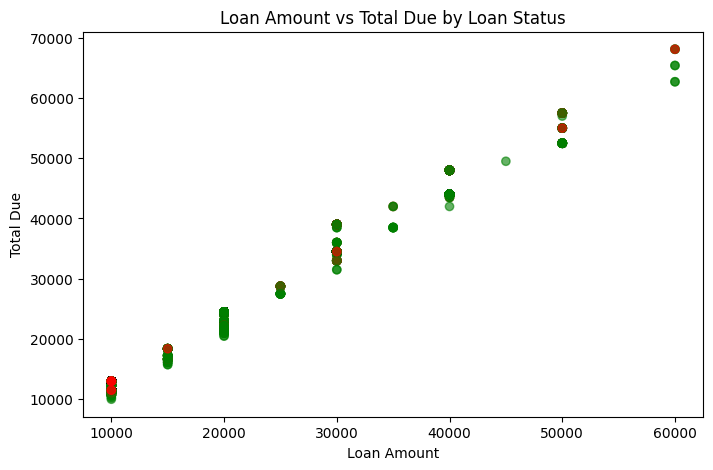

In [1]:
!pip install pandas openpyxl




import pandas as pd

df = pd.read_csv("trainperf.csv")
print(df.shape)
print(df.head())

df.head(10)

df.dtypes

df.info()

df.describe()

df.describe(include='all')

df['good_bad_flag'].value_counts()

df.isnull()

# Count missing values in each column
missing_counts = df.isnull().sum()
print(missing_counts)

missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

df['loanamount'].fillna(df['loanamount'].mean(), inplace=True)
df['termdays'].fillna(df['termdays'].median(), inplace=True)


df['referredby'].fillna(df['referredby'].mode()[0], inplace=True)

df.isnull().sum()


df_selected = df[['customerid', 'loanamount', 'totaldue', 'termdays', 'good_bad_flag', 'referredby']]
df_selected.head()


df_selected['loan_to_due_ratio'] = df_selected['totaldue'] / df_selected['loanamount']
df_selected.head()


df_selected['loan_per_day'] = df_selected['loanamount'] / df_selected['termdays']
df_selected

df_selected.groupby('good_bad_flag')['loanamount'].mean()


df_selected.groupby('referredby').agg({
    'loanamount': 'sum',
    'termdays': 'mean',
    'totaldue': 'mean'
})


df_selected.groupby('good_bad_flag').size()


df_selected.sort_values(by='loanamount', ascending=False).head(10)


!pip install matplotlib


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['loanamount'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()


loan_status_counts = df['good_bad_flag'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(loan_status_counts.index, loan_status_counts.values, color=['green', 'red'])
plt.title('Count of Loans by Good/Bad Flag')
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['loanamount'], df['totaldue'], color='purple', alpha=0.6)
plt.title('Loan Amount vs Total Due')
plt.xlabel('Loan Amount')
plt.ylabel('Total Due')
plt.show()


colors = {'Good':'green', 'Bad':'red'}
plt.figure(figsize=(8,5))
plt.scatter(df['loanamount'], df['totaldue'],
            c=df['good_bad_flag'].map(colors), alpha=0.6)
plt.title('Loan Amount vs Total Due by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Total Due')
plt.show()


